# Przekształcenia punktowe

W trakcie niniejszego ćwiczenia zapoznamy się z podstawowymi operacjami punktowymi (bezkontekstowymi) przeprowadzanymi na obrazach cyfrowych:
- typu LUT (operacja jednoargumentowa),
- arytmetycznymi (operacje dwuargumentowe): dodawanie, odejmowanie, mnożenie, dzielenie,
- logicznymi (operacje jedno i dwuargumentowe): AND, OR, XOR, NOT.

Na początku zaimportuj potrzebne biblioteki.

In [ ]:
import cv2
import os
import requests
import numpy as np
import matplotlib.pyplot as plt

## Operacja LUT

**Operacja LUT** polega na przekształcaniu wartości poszczególnych pikseli obrazu przy użyciu z góry przygotowanych tabel przekodowań (tabel korekcji).

W przetwarzaniu obrazów najczęściej wykorzystuje się następujące funkcje:
- typu kwadratowa, pierwiastek kwadratowy
- typu logarytm, odwrócony logarytm
- typu wykładnicza,
- inne (np. piłokształtna).

W tym zadaniu zostały dla Państwa przygotowane tablice przekodowania.
Proszę pobrać je z githuba `https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lut.py` (można użyć znanej biblioteki request), a następnie zaimportować je poleceniem `import lut`.
Od tego momentu można się do nich odwoływać w następujący sposób: `lut.log` itd.

In [ ]:
url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/'
fileName = 'lut.py'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

Wyświetl przykładowe przekodowanie wykorzystując funkcję `plt.plot(lut.kwadratowa)`.

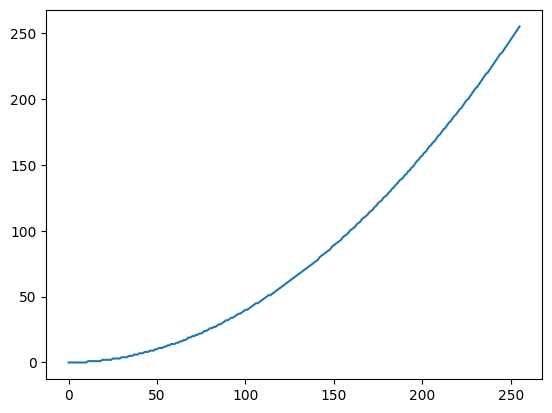

In [ ]:
import lut
plt.plot(lut.kwadratowa)

Wybierz jeden z obrazów: _lena.bmp_ lub _jet.bmp_ (w razie potrzeby pobierz go z githuba):
- https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lena.bmp
- https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/jet.bmp

Wczytaj go i wyświetl.

In [ ]:
fileName = 'lena.bmp'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

fileName2 = 'jet.bmp'
if not os.path.exists(fileName2) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

Na wybranym obrazie wykonaj operację LUT.
Służy do tego funkcja `cv2.LUT` przyjmująca dwa argumenty: obraz oraz tablicę przekodowania.
Wybierz dowolną z zaimportowanych tablic i wyświetl wynikowy obraz.

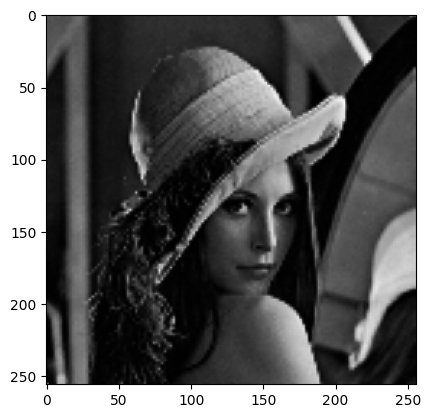

In [ ]:
im = cv2.imread(fileName, cv2.IMREAD_GRAYSCALE)
im_lut = cv2.LUT(im, lut.kwadratowa)
plt.imshow(im_lut, cmap='gray')

Aby lepiej zobaczyć w jaki sposób działają różne przekodowania LUT, skonstruujemy funkcję, która jako argumenty pobierać będzie obrazek oryginalny oraz tablicę przekodowania, a następnie na wspólnym rysunku będzie wyświetlać: funkcję, obraz wejściowy oraz wynik przekodowania.

Przypomnienie składni tworzenia funkcji w pythonie:
```{python}
  def nazwa_funkcji(para, metry):
  	# cialo funkcji
```

  - Stwórz nową funkcję i nazwij ją LUT.
  - Funkcja powinna przyjmować dwa parametry: obraz oraz tablicę przekodowania.
  - W ciele funkcji wykonaj przekodowanie LUT, podobnie jak wcześniej w przykładzie.
  - Funkcja powinna wyświetlić wykres składający się z 3 umieszczonych obok siebie pól: wykres przekodowania, obraz oryginalny oraz obraz przekształcony.
    Każdy z wykresów powinien być podpisany.
    _(W razie problemów można przypomnieć sobie te zagadnienia z laboratorium wprowadzającego)_
  - Jeśli wykres przekodowania jest zbyt rozciągnięty, można go wyrównać, np. `ax2.set_aspect('equal')`.

In [ ]:
def LUT(im, table):
    im_lut = cv2.LUT(im, table)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    ax2.plot(table)
    ax2.set_title('Funkcja')
    ax2.set_aspect('equal')

    ax1.imshow(im, cmap='gray')
    ax1.set_title('Oryginalny')
    ax1.set_aspect('equal')

    ax3.imshow(im_lut, cmap='gray')
    ax3.set_title('Przkeształacony')
    ax3.set_aspect('equal')

Wywołaj przygotowaną funkcję dla każdego z przekształceń.
W wyniku powinno powstać 7 wykresów.

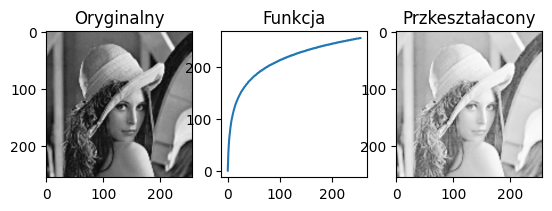

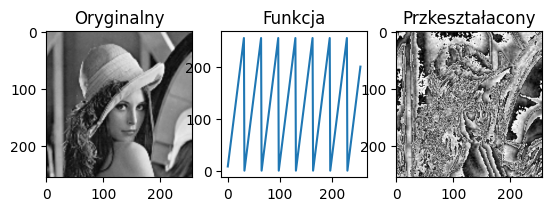

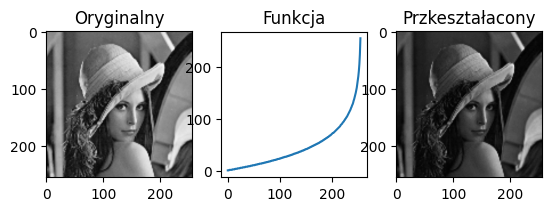

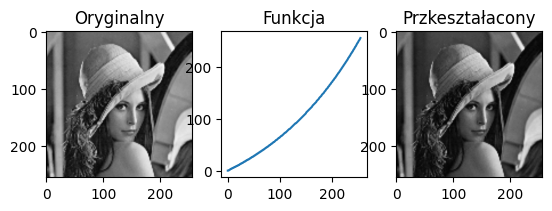

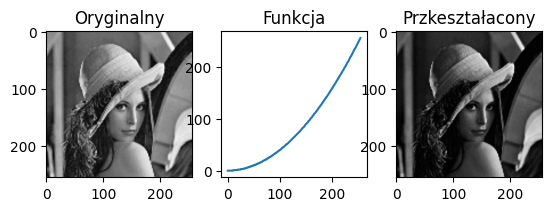

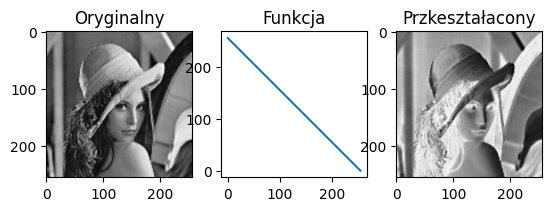

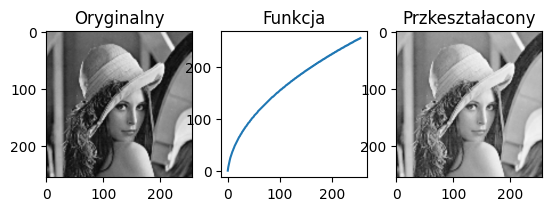

In [ ]:
for table in [lut.log, lut.pila, lut.odwlog, lut.wykladnicza, lut.kwadratowa, lut.odwrotna, lut.pierwiastkowa]:
    LUT(im, table)

## Operacja arytmetyczne

### Dodawanie

Wczytaj dwa obrazy _lena.bmp_ i _jet.bmp_ i wyświetl je.

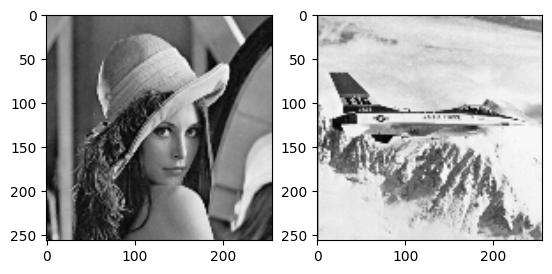

In [ ]:
lena = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)
jet = cv2.imread('jet.bmp', cv2.IMREAD_GRAYSCALE)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(lena, cmap='gray')
ax2.imshow(jet, cmap='gray')

Dodaj obrazy _lena_ i _jet_, wykorzystaj funkcję `cv2.add`.
Uzyskany wynik wyświetl.

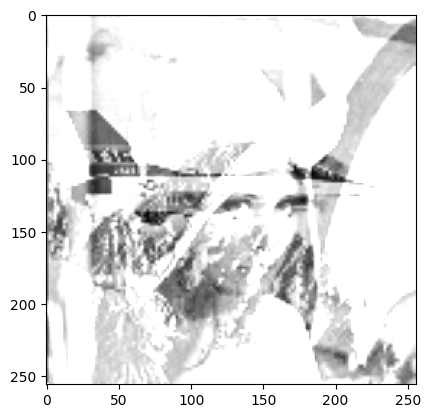

In [ ]:
sum = cv2.add(lena, jet)
plt.imshow(sum, cmap='gray')

Czy wynik sumowania jest satysfakcjonujący?
Co może niekorzystnie wpływać na rezultat operacji?
Spróbuj wykonać dodawanie ponownie wykorzystując typ uint16 (`jet.astype('uint16')`) dla arguemntów dodawania.
Wynikowy obraz należy przeskalować do zakresu 0-255, zamienić na typ uint8 i wyświetlić.
**Uwaga: operacja ta jest użyteczna w przypadku, gdy dane do wyświetlenia wykraczają poza zakres 0-255, w przeciwnym przypadku jej wykorzystanie może zniekształcić wyniki.**

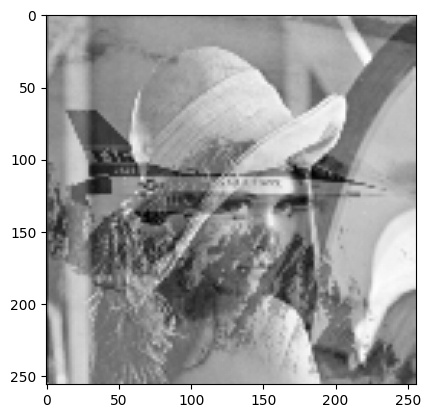

In [ ]:
# Wynik dodawania jest niesatysfakcjonujący,
# bardzo duża częśc pikseli jest biała,
# wynika to z faktu, że funkcja cv2.add, dla wyników dodawania > 255
# obcina zakres, czyli wstawia 255
sum = cv2.add(lena.astype('uint16'), jet.astype('uint16'))
sum = (sum/np.max(sum)*255).astype('uint8')
plt.imshow(sum, cmap='gray')

### Kombinacja liniowa

Do wykonywania operacji kombinacji liniowej służy funkcja `cv2.addWeighted`.
Zapoznaj się z dokumentacją tej funkcji i przetestuj kilka kombinacji liniowych obrazów _lena_ i _jet_.
Wyświetl wynik dowolnej z nich.

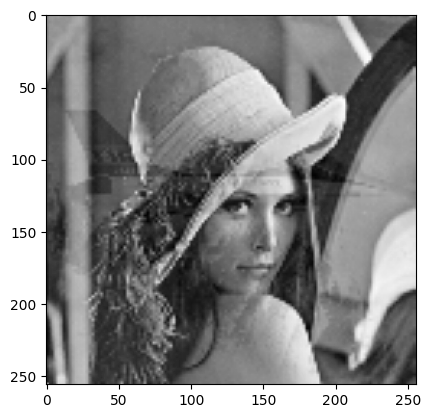

In [ ]:
sum_weighted = cv2.addWeighted(lena, 0.8, jet, 0.2, 0)
plt.imshow(sum_weighted, cmap='gray')

### Odejmowanie

Wykorzystując funkcję `cv2.subtract` odejmij obrazy _lena_ i _jet_.

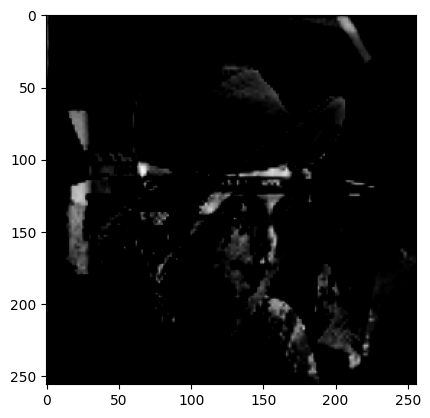

In [ ]:
diff = cv2.subtract(lena, jet)
plt.imshow(diff, cmap='gray')

Czy wynik odejmowania jest satysfakcjonujący?
Co może niekorzystnie wpływać na rezultat operacji?
Często zamiast zwykłego odejmowania wykorzystuje się operację wartość bezwzględna z różnicy (pozwala to między innymi uniknąć pokazanych powyżej problemów).
Zamień typ argumentów _lena_ i _jet_ z uint8 na **int16**, odejmij je od siebie, a następnie wykorzystując funkcję `np.abs` wykonaj operację wartość bezwzględna z różnicy.
Wyświetl ten obraz.
Zastanów się, dlaczego ta zmiana poprawia wynik odejmowania?

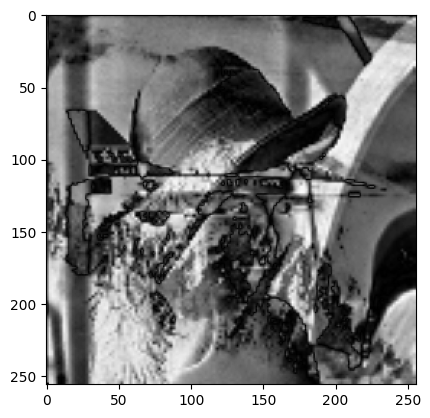

In [ ]:
# Wynik odejmowania nie jest satysfakcjonujący,ponieważ
# przekraczamy zakres(wartości < 0) w tym przypadku
# skutkuje to bardzo wieloma zerami, przez co wynik jest bardzo ciemny

diff = cv2.subtract(lena.astype('int16'), jet.astype('int16'))
diff = np.abs(diff)
plt.imshow(diff, cmap='gray')

# Zastosowanie wartości bezwględnej poprawia wynik, ponieważ
# przy odejmowaniu obrazów często nie obchodzi nas znak
# różnicy(czy jest dodatnia czy ujemna), a jedynie jej
# "amplituda"

### Mnożenie

Mnożenie dwóch obrazów pozwala wykonać funkcja `cv2.multiply`.
Wykonaj mnożenie obrazów _lena_ i _jet_.
Czy wynik takiej operacji zawiera jakąś istotną informację?
Dlaczego?

Przed wykonaniem mnożenia zamień typ arguemntów na **float64**. Wynik mnożenia przeskaluj do zakresu 0-255, a następnie zrzutuj na typ **uint8**.

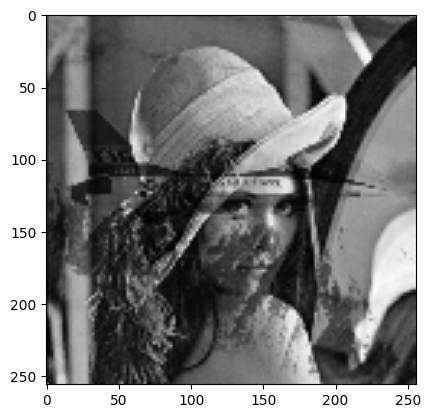

In [ ]:
prod = cv2.multiply(lena.astype('float64'), jet.astype('float64'))
prod = (prod/np.max(prod)*255).astype('uint8')
plt.imshow(prod, cmap='gray')

# Wynikiem operacji jest obraz, który nie zawiera
# istotnych informacji. Jeżeli pixel jednego obrazu
# jest bliski zera to wynik też będzie ciemny.
# Mnożenie obrazów jest operacją nieodwracalną i tracimy
# jej wyniku informację.

Mnożenie częściej wykorzystuje się jako:
  + mnożenie przez stałą $-$ co powoduje ogólne rozjaśnienie albo ściemnienie obrazu,
  + mnożenie przez maskę $-$ czyli obraz binarny.

Wczytaj maskę _kolo.bmp_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp).
Przemnóż wybrany obraz przez maskę i wyświetl wynik.
Mnożenie przez maskę można zrealizować za pomocą funkcji `cv2.multiply`, ale maskę należy należy najpierw przekształcić z zakresu 0-255 do 0-1, na przykład `(maska).astype('bool').astype('uint8')`.

In [ ]:
fileName = 'kolo.bmp'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

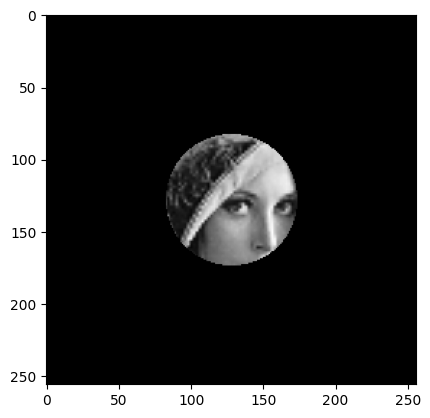

In [ ]:
circle = cv2.imread('kolo.bmp', cv2.IMREAD_GRAYSCALE)
circle = circle.astype('bool').astype('uint8')
lena_circle = cv2.multiply(lena, circle)
plt.imshow(lena_circle, cmap='gray')


### Negatyw

Negatyw obrazu uzyskuje się za pomocą funkcji `cv2.bitwise_not(img)`
Negatyw obrazu można również uzyskać wykorzystując przekodowanie LUT.
Można w tym celu posłużyć się przygotowaną wcześniej tablicą `lut.odwrotna`.
Przetestuj działanie tych funkcji i wykonaj negatyw obrazu _lena_ dowolnym sposobem.

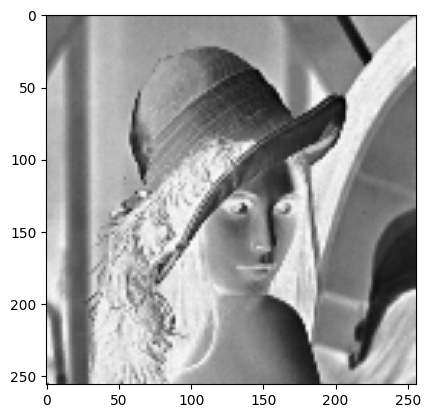

In [ ]:
neg = cv2.bitwise_not(lena)
plt.imshow(neg, cmap='gray')

## Operacje logiczne

Na poszczególnych punktach obrazu (najczęściej binarnego $-$ czyli składającego się z dwóch kolorów: czarnego i białego) można wykonywać operacje logiczne: NOT, AND, OR, XOR itp.
Wczytaj dwa obrazy: _kolo.bmp_ i _kwadrat.bmp_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kwadrat.bmp), następnie wyświetl je.

In [ ]:
fileName = 'kwadrat.bmp'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

Na wczytanych obrazach wykonaj wybrane operacje logiczne: NOT (operator `~`), AND (`&`), OR (`|`), XOR (`^`).
Operator `~` jest jednoargumentowy, wszystkie pozostałe są dwuargumentowe.
Alternatywnym sposobem jest wykorzystanie funkcji z biblioteki opencv: `cv2.bitwise_not`, `cv2.bitwise_and`, `cv2.bitwise_or`, `cv2.bitwise_xor`.
Wyświetl rezultaty.

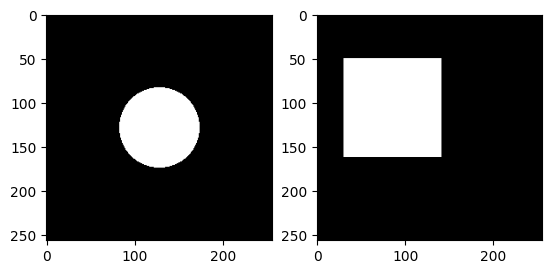

In [ ]:
circle = cv2.imread('kolo.bmp', cv2.IMREAD_GRAYSCALE).astype('bool').astype('uint8')
square = cv2.imread('kwadrat.bmp', cv2.IMREAD_GRAYSCALE).astype('bool').astype('uint8')

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(circle, cmap='gray')
ax2.imshow(square, cmap='gray')

Text(0.5, 1.0, 'NOT(Square)')

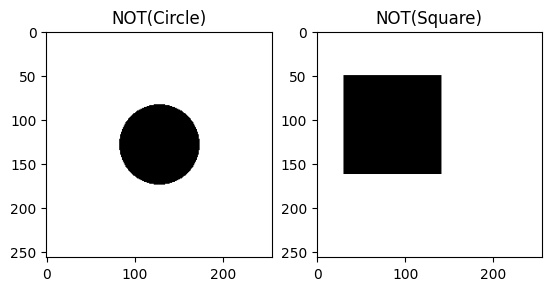

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(cv2.bitwise_not(circle), cmap='gray')
ax1.set_title('NOT(Circle)')
ax2.imshow(cv2.bitwise_not(square), cmap='gray')
ax2.set_title('NOT(Square)')

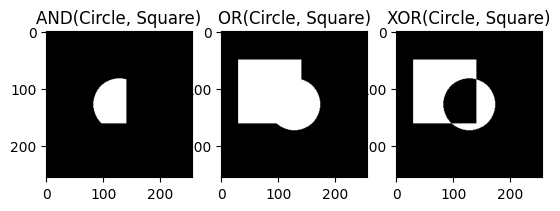

In [ ]:
fig, axs = plt.subplots(1, 3)

for (ax, (f, desc)) in zip(axs.flatten(), [
    (cv2.bitwise_and, 'AND'),
    (cv2.bitwise_or, 'OR'),
    (cv2.bitwise_xor, 'XOR'),
]):
    ax.imshow(f(circle, square), cmap='gray')
    ax.set_title(desc + '(Circle, Square)')